# Project A3 “Motor imagery classification from EEG for brain computer interface”

## Introduction

Motor Imagery (MI) refers to the mental simulation of movement without any actual physical execution. EEG-based MI classification is a core component of Brain–Computer Interface (BCI) systems, enabling direct communication between the brain and external devices by decoding neural activity patterns associated with imagined movements.

In this notebook, we explore different end-to-end pipelines for **EEG Motor Imagery classification using Python**. The workflow includes EEG data loading, preprocessing, feature extraction, and supervised machine learning–based classification. 

In [74]:
import importlib
import scipy.io
import utils.utils as u 
import utils.preprocessing as p 
import utils.models as m 
import numpy as np
import mne
import polars as pl
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
import random
import matplotlib.pyplot as plt
from mne.decoding import CSP

# Reload modules to reflect recent changes:
importlib.reload(u)
importlib.reload(p)
importlib.reload(m)

SEED=42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [2]:
#Load files from directory of the experiment
files=u.get_file_names("../data", experiment="CLA")
print(files)

['../data/CLA-SubjectA-160108-3St-LRHand.mat', '../data/CLA-SubjectB-151019-3St-LRHand.mat', '../data/CLA-SubjectB-151020-3St-LRHand.mat', '../data/CLA-SubjectB-151215-3St-LRHand.mat', '../data/CLA-SubjectC-151126-3St-LRHand.mat', '../data/CLA-SubjectC-151216-3St-LRHand.mat', '../data/CLA-SubjectC-151223-3St-LRHand.mat', '../data/CLA-SubjectD-151125-3St-LRHand.mat', '../data/CLA-SubjectE-151225-3St-LRHand.mat', '../data/CLA-SubjectE-160119-3St-LRHand.mat', '../data/CLA-SubjectE-160122-3St-LRHand.mat', '../data/CLA-SubjectF-150916-3St-LRHand.mat', '../data/CLA-SubjectF-150917-3St-LRHand.mat', '../data/CLA-SubjectF-150928-3St-LRHand.mat', '../data/CLA-SubjectJ-170504-3St-LRHand-Inter.mat', '../data/CLA-SubjectJ-170508-3St-LRHand-Inter.mat', '../data/CLA-SubjectJ-170510-3St-LRHand-Inter.mat']


In [3]:
FILE=files[0] #Choose one file for now, later we will loop over all files
mat_data = scipy.io.loadmat(FILE)
print(f"The file includes metadata coming from python that we don't need:{mat_data.keys()}.\n")
print(f"For now we will focus on the 'o' key which contains the EEG data and information about the experiment.\n")

subject_info = ((FILE.split("/")[-1]).split(".")[0]).split("-") #We can extract subject info from the file name
data = mat_data['o'][0, 0]       
print(f"Data keys include:{data.dtype.names}.\n") 
sfreq = int(data['sampFreq'][0, 0]) if data['sampFreq'].size > 0 else 200
eeg_data = data['data'].T  # Shape: (n_channels, n_samples)
channel_names = [
    str(ch[0]).strip("[]' ")
    for ch in data["chnames"]
]
info = mne.create_info(
            ch_names=channel_names,
            sfreq=sfreq,
            ch_types='eeg'
        )
        
info.set_channel_types({"X5": "misc"}) # Set 'X5' as misc type to avoid errors
montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage)
raw = mne.io.RawArray(eeg_data, info)
print(raw.info)

The file includes metadata coming from python that we don't need:dict_keys(['__header__', '__version__', '__globals__', 'o']).

For now we will focus on the 'o' key which contains the EEG data and information about the experiment.

Data keys include:('id', 'tag', 'sampFreq', 'nS', 'marker', 'data', 'chnames', 'binsuV').

Creating RawArray with float64 data, n_channels=22, n_times=671600
    Range : 0 ... 671599 =      0.000 ...  3357.995 secs
Ready.
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, A1, A2, F7, F8, T3, ...
 chs: 21 EEG, 1 misc
 custom_ref_applied: False
 dig: 24 items (3 Cardinal, 21 EEG)
 highpass: 0.0 Hz
 lowpass: 100.0 Hz
 meas_date: unspecified
 nchan: 22
 projs: []
 sfreq: 200.0 Hz
>


C:\Users\josub\AppData\Local\Temp\ipykernel_25348\1191536505.py:21: RuntimeWarning: The unit for channel(s) X5 has changed from V to NA.
  info.set_channel_types({"X5": "misc"}) # Set 'X5' as misc type to avoid errors


In [4]:
print("The windows and sync is not perfect")
labels = np.array(data['marker'])
import numpy as np
from itertools import groupby
grouped_data = []
for k, g in groupby(labels):
    series_length = len(list(g))
    grouped_data.append((k, series_length))
for marker, length in grouped_data[:10]:
    if marker != 0:  # Only print non-zero markers
        print(f"Marker {marker}: Length {length}")
non_zero_lengths = [length for k, length in grouped_data if k != 0]
if non_zero_lengths:
    print(f"\nMinimum length of a non-zero marker series: {min(non_zero_lengths)}")
    
print("This is not the 170 samples we expected, let's check what is going on")

The windows and sync is not perfect
Marker [3]: Length 203
Marker [3]: Length 203
Marker [1]: Length 203
Marker [1]: Length 204
Marker [2]: Length 203

Minimum length of a non-zero marker series: 202
This is not the 170 samples we expected, let's check what is going on


Sync channel data (first 10 samples): [-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
Spike indixes:[1855 1856 1857 1858 1859 1860 1861 1862 3060 3061]
Compute gaps:[   1    1    1    1    1    1    1 1198    1    1]
Indices in gaps:[ 7 18 42 72 73 74 76 78 81 84]
Spike onsets in the plotted window: [100399 101084 101634]


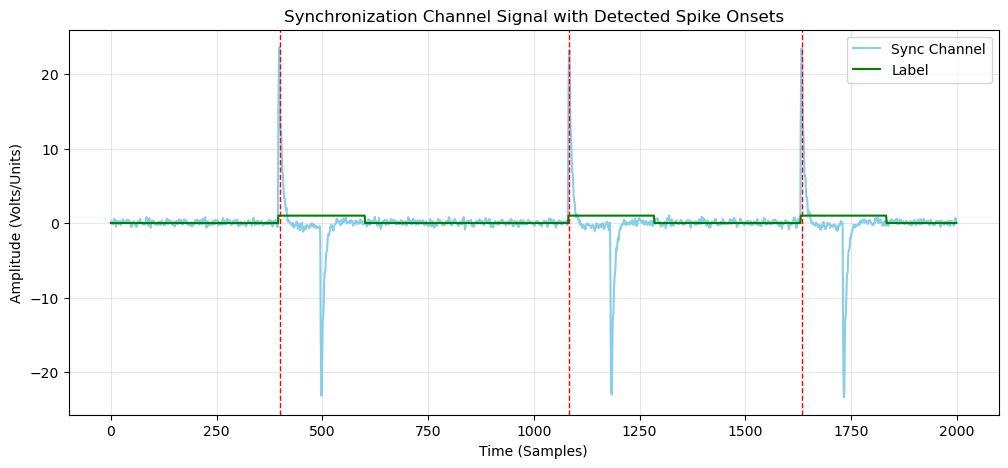

In [5]:
COLOR_MAP = {
    0: 'gray',    # Baseline/Rest
    1: 'blue',    # Mental Imagery 1
    2: 'red',     # Mental Imagery 2
    3: 'green',   # Mental Imagery 3 
}
THRESHOLD=20
sync_data = raw.get_data(picks='X5').flatten()
print(f"Sync channel data (first 10 samples): {sync_data[:10]}")
spikes=np.where(sync_data> 20)[0]
print(f"Spike indixes:{spikes[:10]}")
gaps = np.diff(spikes)
print(f"Compute gaps:{gaps[:10]}")

indices_in_gaps = np.where(gaps > 2)[0]
print(f"Indices in gaps:{indices_in_gaps[:10]}")
first_spike= spikes[0]
subsequent_spikes = spikes[indices_in_gaps]
final_spike_onsets = np.concatenate([[first_spike], subsequent_spikes])


START_OFFSET = 100000
WINDOW= 2000
plt.figure(figsize=(12, 5))
plt.plot(range(WINDOW), sync_data[START_OFFSET: START_OFFSET+WINDOW], label='Sync Channel', color='skyblue')
plt.plot(range(WINDOW), data["marker"][START_OFFSET: START_OFFSET+WINDOW], label='Label', color='green')

spikes_plot = final_spike_onsets[(final_spike_onsets >= START_OFFSET) & (final_spike_onsets < START_OFFSET + WINDOW)]
print(f"Spike onsets in the plotted window: {spikes_plot}")
for onset in spikes_plot:
    # Only label the first vertical line for a clean legend
    plt.axvline(x=onset-START_OFFSET, color='red', linestyle='--', linewidth=1)


plt.title('Synchronization Channel Signal with Detected Spike Onsets')
plt.xlabel('Time (Samples)')
plt.ylabel('Amplitude (Volts/Units)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



The syncronization seems to be right we just need to change the length of the windows to be consistent

In [6]:
#NOTE THIS WAY WE WILL ALSO HAVE 0 EVENTS
markers_diff = np.diff(data["marker"].squeeze())
print(f"Markers : {data['marker'][:10]}")
print(f"Size of data['marker']: {len(data['marker'])}")
print(f"Print markers_diff (first 10): {markers_diff[:10]}")

event_samples = np.where(markers_diff !=0)
print(f"Event samples (first 10): {event_samples[0][:10]}")
event_count = len(event_samples[0])
print(f"Total Events Found: {event_count}")

# Get event values (your labels)
event_values = data["marker"].squeeze()[event_samples[0]+ 1]
events = np.column_stack([
        event_samples[0]+1, 
        np.zeros(event_count, dtype=int), 
        event_values
    ]).astype(int)

print(f"Events (first 10): {events[:10]}")
    

Markers : [[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]
Size of data['marker']: 671600
Print markers_diff (first 10): [0 0 0 0 0 0 0 0 0 0]
Event samples (first 10): [37271 37474 37782 37985 38369 38572 39021 39225 39554 39757]
Total Events Found: 1920
Events (first 10): [[37272     0     3]
 [37475     0     0]
 [37783     0     3]
 [37986     0     0]
 [38370     0     1]
 [38573     0     0]
 [39022     0     1]
 [39226     0     0]
 [39555     0     2]
 [39758     0     0]]


In [7]:
eeg_channels = [ch for ch in channel_names if ch not in ['X5','X3']]
# --- Option A: A1-A2 Average Reference ---
raw_a1a2 = raw.copy().set_eeg_reference(ref_channels=['A1', 'A2'])
# --- Option B: Common Average Reference (CAR) ---
# Use the average of all EEG channels defined in the 10-20 configuration
raw_car = raw.copy().set_eeg_reference(ref_channels=eeg_channels)
# --- Option C: Laplace Reference (Surface Laplacian) ---
# In MNE, this is often done by calculating the Surface Laplacian.
raw_laplace = mne.preprocessing.compute_current_source_density(raw.copy().pick("eeg"))

EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Fitted sphere radius:         95.6 mm
Origin head coordinates:      -0.9 15.8 45.4 mm
Origin device coordinates:    -0.9 15.8 45.4 mm


Effective window size : 10.240 (s)
Plotting power spectral density (dB=True).


C:\Users\josub\AppData\Roaming\Python\Python312\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


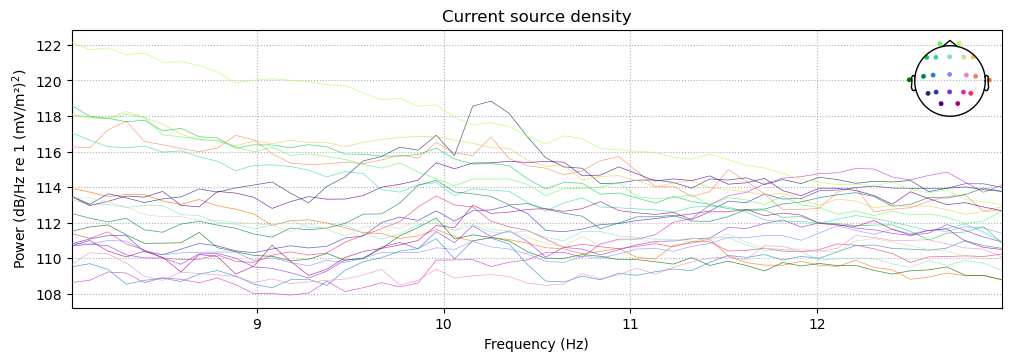

In [ ]:
#spectrum = raw_laplace.compute_psd(method='welch', fmin=8.0, fmax=13.0)
#plot = spectrum.plot()

In [8]:
epochs_a1a2 = mne.Epochs(
    raw=raw_a1a2,
    events=events,
    tmin=0,
    tmax=0.85,
    baseline=None,
    preload=True,
    picks=['eeg']
)
epochs_car = mne.Epochs(
    raw=raw_car,
    events=events,
    tmin=0,
    tmax=0.85,
    baseline=None,
    preload=True,
    picks=['eeg']
)
epochs_laplace = mne.Epochs(
    raw=raw_laplace,
    events=events,
    tmin=0,
    tmax=0.85,
    baseline=None,
    preload=True
)
EPOCHS=epochs_laplace

Not setting metadata
1920 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1920 events and 171 original time points ...
0 bad epochs dropped
Not setting metadata
1920 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1920 events and 171 original time points ...
0 bad epochs dropped
Not setting metadata
1920 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1920 events and 171 original time points ...
0 bad epochs dropped


In [ ]:
#freqs = np.arange(5., 50., 1.) # 5 Hz to 49 Hz, in 1 Hz steps

# Compute TFR using multitaper (an advanced, robust FFT-based spectrogram)
#power = epochs_laplace.compute_tfr(
#   method='multitaper',
#    freqs=freqs,
#    n_cycles=freqs / 2.,  # Number of cycles for the taper (a common heuristic)
#    return_itc=False,  # We only want power, not Inter-Trial Coherence (ITC)
#    decim=3, # Downsample for speed
#    average=True # Average power across all epochs to get the mean spectrogram
#)

No baseline correction applied


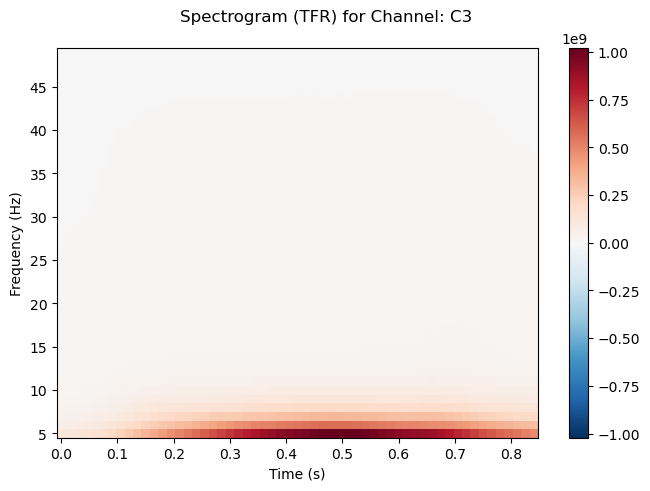

[<Figure size 640x480 with 2 Axes>]

In [ ]:
#power.plot(
#    picks="A2", 
#   baseline=None, # Correct the data relative to the baseline period
#    mode='logratio', # Show power changes as log(power / baseline_power)
#    title=f'Spectrogram (TFR) for Channel: C3',
#    show=True
#)

In [84]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

X = EPOCHS.get_data()  # (n_epochs, n_channels, n_times)
y= EPOCHS.events[:, 2]
unique_labels = np.unique(y)
N = len(unique_labels)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y),
    y=y
)

# Convert to dict {class_index: weight}
class_weights = dict(enumerate(class_weights_array))
print(class_weights)

print(X_train.shape, X_val.shape, X_test.shape)


{0: 0.5, 1: 1.5894039735099337, 2: 1.411764705882353, 3: 1.509433962264151}
(1344, 21, 171) (288, 21, 171) (288, 21, 171)


EXTRACTED FEATURES

In [ ]:
from joblib import Parallel, delayed
freq_bands = [[4, 8], [8, 12], [12, 16], [16, 20], [20, 24], [24, 28], [28, 32], [32,36], [36,40]]
all_sequences = []

# 1. Initialize storage
trained_csp_bank = []
train_seq, val_seq, test_seq = [], [], []

def extract_windows(data, n_steps=10):
    n_samples = data.shape[-1]
    win_len = int(n_samples * 0.5) 
    start_indices = np.linspace(0, n_samples - win_len, n_steps).astype(int)
    
    sections = []
    for start in start_indices:
        sections.append(data[..., start:start+win_len])
    return sections

def process_band_to_matrix(low, high, X_train, y_train, X_val, X_test, sfreq):
    # Filter
    xt_b = mne.filter.filter_data(X_train, sfreq, low, high, method='iir', verbose=False)
    xv_b = mne.filter.filter_data(X_val, sfreq, low, high, method='iir', verbose=False)
    xte_b = mne.filter.filter_data(X_test, sfreq, low, high, method='iir', verbose=False)

    csp = CSP(n_components=4, reg='ledoit_wolf', log=True)
    csp.fit(xt_b, y_train)
    W = csp.filters_ 

    def get_matrices(dataset):
        cnn_mats = []
        rnn_mats = []
        
        for trial in dataset:
            # Generate CNN windows (T=3)
            sec_cnn = extract_windows(trial, n_steps=3)
            # Generate RNN windows (T=10) - SWC Strategy
            sec_rnn = extract_windows(trial, n_steps=15)
            
            # Helper to calculate log-var for a list of sections
            def calc_logvar(sections):
                cols = []
                for sec in sections:
                    proj = np.dot(W, sec)
                    cols.append(np.log(np.var(proj, axis=1)))
                return np.stack(cols, axis=1) # Shape: (Components, T)

            cnn_mats.append(calc_logvar(sec_cnn))
            rnn_mats.append(calc_logvar(sec_rnn))
            
        return np.array(cnn_mats), np.array(rnn_mats)

    train_cnn, train_rnn = get_matrices(xt_b)
    val_cnn, val_rnn     = get_matrices(xv_b)
    test_cnn, test_rnn   = get_matrices(xte_b)

    return (train_cnn, val_cnn, test_cnn), (train_rnn, val_rnn, test_rnn)

# --- Parallel Execution ---
results = Parallel(n_jobs=-1)(delayed(process_band_to_matrix)(l, h, X_train, y_train, X_val, X_test, sfreq) 
                              for l, h in freq_bands)
# Extract CNN data: index r[0] contains (train, val, test)
X_train_cnn = np.concatenate([r[0][0] for r in results], axis=1) # (Trials, 36, 3)
X_val_cnn   = np.concatenate([r[0][1] for r in results], axis=1)
X_test_cnn  = np.concatenate([r[0][2] for r in results], axis=1)

# Extract RNN data: index r[1] contains (train, val, test)
X_train_rnn = np.concatenate([r[1][0] for r in results], axis=1) # (Trials, 36, 15)
X_val_rnn   = np.concatenate([r[1][1] for r in results], axis=1)
X_test_rnn  = np.concatenate([r[1][2] for r in results], axis=1)

# Transpose RNN to (Trials, Time, Features) for LSTM/GRU
X_train_rnn = np.transpose(X_train_rnn, (0, 2, 1)) # (Trials, 15, 36)
X_val_rnn   = np.transpose(X_val_rnn, (0, 2, 1))
X_test_rnn  = np.transpose(X_test_rnn, (0, 2, 1))

print(f"CNN Shape: {X_train_cnn.shape}")
print(f"RNN Shape: {X_train_rnn.shape}")

CNN Shape: (1344, 187, 3)
RNN Shape: (1344, 15, 187)


In [82]:
from sklearn.preprocessing import StandardScaler
import numpy as np

n_train_cnn, height_cnn, width_cnn = X_train_cnn.shape
n_val_cnn = X_val_cnn.shape[0]
n_test_cnn = X_test_cnn.shape[0]

scaler_cnn = StandardScaler()

X_train_cnn_flat = X_train_cnn.reshape(n_train_cnn, -1)
X_train_cnn_scaled = scaler_cnn.fit_transform(X_train_cnn_flat)
X_val_cnn_flat = X_val_cnn.reshape(n_val_cnn, -1)
X_val_cnn_scaled = scaler_cnn.transform(X_val_cnn_flat)
X_test_cnn_flat = X_test_cnn.reshape(n_test_cnn, -1)
X_test_cnn_scaled = scaler_cnn.transform(X_test_cnn_flat)

n_train_rnn, n_steps_rnn, n_features_rnn = X_train_rnn.shape
n_val_rnn = X_val_rnn.shape[0]
n_test_rnn = X_test_rnn.shape[0]

scaler_rnn = StandardScaler()

X_train_rnn_flat = X_train_rnn.reshape(-1, n_features_rnn)
X_train_rnn_scaled = scaler_rnn.fit_transform(X_train_rnn_flat)
X_val_rnn_flat = X_val_rnn.reshape(-1, n_features_rnn)
X_val_rnn_scaled = scaler_rnn.transform(X_val_rnn_flat)
X_test_rnn_flat = X_test_rnn.reshape(-1, n_features_rnn)
X_test_rnn_scaled = scaler_rnn.transform(X_test_rnn_flat)

In [85]:
times = EPOCHS.times
n_epochs, n_channels, n_times = X.shape
C = X.shape[1]
T = X.shape[2]
print(f"C: {C}, T: {T}, N: {N}")
print("#####################################################\n")


X_train = X_train[:, :, :, np.newaxis] 
X_test = X_test[:, :, :, np.newaxis]   
X_val = X_val[:, :, :, np.newaxis]  

X_train_features_cnn = X_train_cnn_scaled.reshape(n_train_cnn, height_cnn, width_cnn, 1)
X_val_features_cnn   = X_val_cnn_scaled.reshape(n_val_cnn, height_cnn, width_cnn, 1)
X_test_features_cnn  = X_test_cnn_scaled.reshape(n_test_cnn, height_cnn, width_cnn, 1)


X_train_features_rnn = X_train_rnn_scaled.reshape(n_train_rnn, n_steps_rnn, n_features_rnn)
X_val_features_rnn   = X_val_rnn_scaled.reshape(n_val_rnn, n_steps_rnn, n_features_rnn)
X_test_features_rnn   = X_test_rnn_scaled.reshape(n_test_rnn, n_steps_rnn, n_features_rnn)

label_map = {old: new for new, old in enumerate(unique_labels)}
print("Label map:", label_map)
y_train = np.array([label_map[int(l)] for l in y_train])
y_test = np.array([label_map[int(l)] for l in y_test])
y_val = np.array([label_map[int(l)] for l in y_val])
y_train = to_categorical(y_train, num_classes=N)
y_test = to_categorical(y_test, num_classes=N)
y_val = to_categorical(y_val, num_classes=N)

print("\n")
print("#####################################################\n")
print(f"X train shape: {X_train.shape}, X_train_features shape: {X_train_features_cnn.shape}, y train shape: {y_train.shape}")
print(f"X test shape: {X_test.shape}, X_test_features shape: {X_test_features_cnn.shape}, y test shape: {y_test.shape}")
print(f"X val shape: {X_val.shape}, X_val_features shape: {X_val_features_cnn.shape}, y val shape: {y_val.shape}")

C: 21, T: 171, N: 4
#####################################################

Label map: {0: 0, 1: 1, 2: 2, 3: 3}


#####################################################

X train shape: (1344, 21, 171, 1), X_train_features shape: (1344, 187, 3, 1), y train shape: (1344, 4)
X test shape: (288, 21, 171, 1), X_test_features shape: (288, 187, 3, 1), y test shape: (288, 4)
X val shape: (288, 21, 171, 1), X_val_features shape: (288, 187, 3, 1), y val shape: (288, 4)


In [86]:
import tensorflow as tf
epsilon = 1e-7 

def f1_score_metric(y_true, y_pred):
        
    # Calculate True Positives: (y_true * y_pred) clipped to [0, 1] and summed
    true_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_true * y_pred, 0, 1)))
    
    # Calculate Possible Positives (Actual Positives): Sum of true labels
    possible_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_true, 0, 1)))
    
    # Calculate Predicted Positives: Sum of predicted labels
    predicted_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_pred, 0, 1)))

    # 2. Calculate Precision and Recall
    precision = true_positives / (predicted_positives + epsilon)
    recall = true_positives / (possible_positives + epsilon)

    # 3. Calculate F1-Score (Harmonic Mean)
    f1_val = 2 * (precision * recall) / (precision + recall + epsilon)
    
    return f1_val

In [87]:
cnn=m.Simple_CNN(nb_classes=N, input_shape=(X_train_features_cnn.shape[1], X_train_features_cnn.shape[2], 1))
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
cnn.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 187, 3, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 187, 3, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 187, 3, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 93, 3, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 93, 3, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 93, 3, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 46, 3, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 8832)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │       565,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 4)              │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 584,772 (2.23 MB)

 Trainable params: 584,580 (2.23 MB)

 Non-trainable params: 192 (768.00 B)

In [88]:
# Callbacks
early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric', mode='max', patience=15, restore_best_weights=True)
checkpoint_eegnet = ModelCheckpoint("best_cnn.h5",monitor='val_f1_score_metric', mode='max', save_best_only=True)

history = cnn.fit(
    X_train_features_cnn, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val_features_cnn, y_val),
    shuffle=True,
    callbacks=[ checkpoint_eegnet, early_stop_eegnet],
    class_weight=class_weights
)

y_pred = cnn.predict(X_test_features_cnn)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_labels)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)

Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - f1_score_metric: 0.3091 - loss: 3.1224

42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 120ms/step - f1_score_metric: 0.3326 - loss: 2.3752 - val_f1_score_metric: 0.3252 - val_loss: 1.1615
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - f1_score_metric: 0.5077 - loss: 1.2795

42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - f1_score_metric: 0.4954 - loss: 1.3753 - val_f1_score_metric: 0.5390 - val_loss: 1.0948
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - f1_score_metric: 0.6265 - loss: 1.0536

42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - f1_score_metric: 0.5877 - loss: 1.1284 - val_f1_score_metric: 0.5935 - val_loss: 1.1372
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - f1_score_metric: 0.6806 - loss: 0.9179 - val_f1_score_metric: 0.5824 - val_loss: 1.2704
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - f1_score_metric: 0.7468 - loss: 0.6926

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - f1_score_metric: 0.7469 - loss: 0.6970 - val_f1_score_metric: 0.6084 - val_loss: 1.2344
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - f1_score_metric: 0.7873 - loss: 0.5408

...

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - f1_score_metric: 0.9041 - loss: 0.2254 - val_f1_score_metric: 0.6426 - val_loss: 1.3967
Epoch 10/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - f1_score_metric: 0.9304 - loss: 0.2065

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - f1_score_metric: 0.9161 - loss: 0.2317 - val_f1_score_metric: 0.6454 - val_loss: 1.4814
Epoch 11/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - f1_score_metric: 0.9221 - loss: 0.1954

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - f1_score_metric: 0.9142 - loss: 0.2205 - val_f1_score_metric: 0.6784 - val_loss: 1.3292
Epoch 12/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - f1_score_metric: 0.9325 - loss: 0.1712 - val_f1_score_metric: 0.6773 - val_loss: 1.6198
Epoch 13/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - f1_score_metric: 0.9375 - loss: 0.1654 - val_f1_score_metric: 0.6584 - val_loss: 1.6926
Epoch 14/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - f1_score_metric: 0.9413 - loss: 0.1678 - val_f1_score_metric: 0.6628 - val_loss: 1.7619
Epoch 15/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - f1_score_metric: 0.9500 - loss: 0.1389 - val_f1_score_metric: 0.6713 - val_loss: 1.8099
Epoch 16/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - f1_score_metric: 0.9652 - loss: 0.1068

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - f1_score_metric: 0.9659 - loss: 0.1080 - val_f1_score_metric: 0.6956 - val_loss: 1.7366
Epoch 17/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - f1_score_metric: 0.9587 - loss: 0.1060 - val_f1_score_metric: 0.6688 - val_loss: 1.6649
Epoch 18/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - f1_score_metric: 0.9637 - loss: 0.0891 - val_f1_score_metric: 0.6802 - val_loss: 1.8260
Epoch 19/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - f1_score_metric: 0.9639 - loss: 0.0927 - val_f1_score_metric: 0.6759 - val_loss: 1.7559
Epoch 20/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - f1_score_metric: 0.9690 - loss: 0.0865 - val_f1_score_metric: 0.6756 - val_loss: 2.0150
Epoch 21/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - f1_score_metric: 0.9739 - loss: 0.0789 - val_f1_score_metric: 0.6949 - val_loss: 1.5982
Epoch 22/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - f1_score_metric: 0.9759 - loss: 0.0666

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - f1_score_metric: 0.9769 - loss: 0.0629 - val_f1_score_metric: 0.7109 - val_loss: 1.7967
Epoch 23/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - f1_score_metric: 0.9702 - loss: 0.0837 - val_f1_score_metric: 0.6897 - val_loss: 1.9518
Epoch 24/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - f1_score_metric: 0.9704 - loss: 0.0959 - val_f1_score_metric: 0.6842 - val_loss: 1.9420
Epoch 25/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - f1_score_metric: 0.9783 - loss: 0.0793 - val_f1_score_metric: 0.6737 - val_loss: 2.0092
Epoch 26/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - f1_score_metric: 0.9657 - loss: 0.0788 - val_f1_score_metric: 0.6642 - val_loss: 2.0309
Epoch 27/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - f1_score_metric: 0.9743 - loss: 0.0658 - val_f1_score_metric: 0.6864 - val_loss: 2.1124
Epoch 28/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - f1_score_metric: 0.9750 - loss: 0.0831 - val_f1_score_metric: 0.6795 - val_loss: 2.1514
Epoch 29/10

In [89]:
lstm=m.Simple_LSTM(nb_classes=N, input_shape=(X_train_features_rnn.shape[1], X_train_features_rnn.shape[2]))
lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
lstm.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 15, 187)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 15, 187)        │           748 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 15, 64)         │        64,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 15, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 15, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 15, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 4)              │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,880 (347.19 KB)

 Trainable params: 88,250 (344.73 KB)

 Non-trainable params: 630 (2.46 KB)

In [90]:
# Callbacks
early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric', mode='max', patience=15, restore_best_weights=True)
checkpoint_eegnet = ModelCheckpoint("best_lstm.h5",monitor='val_f1_score_metric', mode='max', save_best_only=True)

history = lstm.fit(
    X_train_features_rnn, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val_features_rnn, y_val),
    shuffle=True,
    callbacks=[ checkpoint_eegnet, early_stop_eegnet],
    class_weight=class_weights
)

y_pred = lstm.predict(X_test_features_rnn)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_labels)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)

Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - f1_score_metric: 0.2063 - loss: 5.7539

42/42 ━━━━━━━━━━━━━━━━━━━━ 39s 149ms/step - f1_score_metric: 0.2142 - loss: 5.5596 - val_f1_score_metric: 0.0000e+00 - val_loss: 4.9923
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - f1_score_metric: 0.3181 - loss: 4.8156 - val_f1_score_metric: 0.0000e+00 - val_loss: 4.5830
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - f1_score_metric: 0.4808 - loss: 4.3170

42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - f1_score_metric: 0.4903 - loss: 4.2365 - val_f1_score_metric: 0.2621 - val_loss: 4.1698
Epoch 4/100
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - f1_score_metric: 0.6028 - loss: 3.7672

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - f1_score_metric: 0.6336 - loss: 3.6350 - val_f1_score_metric: 0.5122 - val_loss: 3.8166
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - f1_score_metric: 0.7240 - loss: 3.2277

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - f1_score_metric: 0.7288 - loss: 3.1430 - val_f1_score_metric: 0.5623 - val_loss: 3.5732
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - f1_score_metric: 0.8015 - loss: 2.8536

...

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - f1_score_metric: 0.9708 - loss: 1.0204 - val_f1_score_metric: 0.6504 - val_loss: 2.6080
Epoch 17/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - f1_score_metric: 0.9754 - loss: 0.9543 - val_f1_score_metric: 0.6092 - val_loss: 2.6581
Epoch 18/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - f1_score_metric: 0.9656 - loss: 0.9295 - val_f1_score_metric: 0.6190 - val_loss: 2.6343
Epoch 19/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - f1_score_metric: 0.9529 - loss: 0.9493 - val_f1_score_metric: 0.6377 - val_loss: 2.5384
Epoch 20/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - f1_score_metric: 0.9467 - loss: 0.8999

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - f1_score_metric: 0.9555 - loss: 0.8824 - val_f1_score_metric: 0.6514 - val_loss: 2.4103
Epoch 21/100
40/42 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - f1_score_metric: 0.9739 - loss: 0.8305

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - f1_score_metric: 0.9746 - loss: 0.8044 - val_f1_score_metric: 0.6629 - val_loss: 2.3660
Epoch 22/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - f1_score_metric: 0.9835 - loss: 0.7369

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - f1_score_metric: 0.9858 - loss: 0.7222 - val_f1_score_metric: 0.6653 - val_loss: 2.4388
Epoch 23/100
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - f1_score_metric: 0.9880 - loss: 0.6833

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - f1_score_metric: 0.9866 - loss: 0.6730 - val_f1_score_metric: 0.6863 - val_loss: 2.3971
Epoch 24/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - f1_score_metric: 0.9937 - loss: 0.6177 - val_f1_score_metric: 0.6526 - val_loss: 2.4406
Epoch 25/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - f1_score_metric: 0.9937 - loss: 0.5786 - val_f1_score_metric: 0.6748 - val_loss: 2.4200
Epoch 26/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - f1_score_metric: 0.9922 - loss: 0.5440 - val_f1_score_metric: 0.6563 - val_loss: 2.4223
Epoch 27/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - f1_score_metric: 0.9847 - loss: 0.5302 - val_f1_score_metric: 0.6586 - val_loss: 2.3011
Epoch 28/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - f1_score_metric: 0.9829 - loss: 0.5350 - val_f1_score_metric: 0.6795 - val_loss: 2.2195
Epoch 29/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - f1_score_metric: 0.9624 - loss: 0.6029 - val_f1_score_metric: 0.6852 - val_loss: 2.0974
Epoch 30/100

In [92]:
gru=m.Simple_GRU(nb_classes=N, input_shape=(X_train_features_rnn.shape[1], X_train_features_rnn.shape[2]))
gru.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
gru.summary()

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 15, 187)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 15, 187)        │           748 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 128)            │       121,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 4)              │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,504 (513.69 KB)

 Trainable params: 130,874 (511.23 KB)

 Non-trainable params: 630 (2.46 KB)

In [93]:
# Callbacks
early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric', mode='max', patience=15, restore_best_weights=True)
checkpoint_eegnet = ModelCheckpoint("best_gru.h5",monitor='val_f1_score_metric', mode='max', save_best_only=True)

history = gru.fit(
    X_train_features_rnn, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val_features_rnn, y_val),
    shuffle=True,
    callbacks=[ checkpoint_eegnet, early_stop_eegnet],
    class_weight=class_weights
)

y_pred = gru.predict(X_test_features_rnn)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_labels)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)

Epoch 1/100
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - f1_score_metric: 0.2204 - loss: 5.1333

42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - f1_score_metric: 0.2853 - loss: 4.7089 - val_f1_score_metric: 0.3194 - val_loss: 3.9431
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - f1_score_metric: 0.5239 - loss: 3.5115

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - f1_score_metric: 0.5399 - loss: 3.3831 - val_f1_score_metric: 0.4518 - val_loss: 3.3701
Epoch 3/100
40/42 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - f1_score_metric: 0.6547 - loss: 2.7937

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - f1_score_metric: 0.6773 - loss: 2.6771 - val_f1_score_metric: 0.4858 - val_loss: 2.9823
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - f1_score_metric: 0.7251 - loss: 2.2919

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - f1_score_metric: 0.7395 - loss: 2.2145 - val_f1_score_metric: 0.5023 - val_loss: 2.7694
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - f1_score_metric: 0.7943 - loss: 1.9199

...

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - f1_score_metric: 0.9183 - loss: 0.6958 - val_f1_score_metric: 0.6416 - val_loss: 2.0400
Epoch 20/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - f1_score_metric: 0.9383 - loss: 0.6352 - val_f1_score_metric: 0.6407 - val_loss: 2.0829
Epoch 21/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - f1_score_metric: 0.9686 - loss: 0.5316 - val_f1_score_metric: 0.6306 - val_loss: 2.1048
Epoch 22/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - f1_score_metric: 0.9873 - loss: 0.4435 - val_f1_score_metric: 0.6319 - val_loss: 2.1230
Epoch 23/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - f1_score_metric: 0.9952 - loss: 0.3831 - val_f1_score_metric: 0.6363 - val_loss: 2.1360
Epoch 24/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - f1_score_metric: 0.9970 - loss: 0.3433 - val_f1_score_metric: 0.6319 - val_loss: 2.1872
Epoch 25/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - f1_score_metric: 0.9985 - loss: 0.3078 - val_f1_score_metric: 0.6198 - val_loss: 2.1403
Epoch 26/100

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - f1_score_metric: 0.9869 - loss: 0.2840 - val_f1_score_metric: 0.6443 - val_loss: 1.8368
Epoch 33/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - f1_score_metric: 0.9981 - loss: 0.2403 - val_f1_score_metric: 0.6392 - val_loss: 1.9469
Epoch 34/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - f1_score_metric: 0.9993 - loss: 0.2109 - val_f1_score_metric: 0.6406 - val_loss: 1.9708
Epoch 35/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - f1_score_metric: 1.0000 - loss: 0.1905 - val_f1_score_metric: 0.6358 - val_loss: 1.9674
Epoch 36/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - f1_score_metric: 1.0000 - loss: 0.1741

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - f1_score_metric: 1.0000 - loss: 0.1702 - val_f1_score_metric: 0.6478 - val_loss: 1.9427
Epoch 37/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - f1_score_metric: 0.9993 - loss: 0.1553 - val_f1_score_metric: 0.6339 - val_loss: 1.9838
Epoch 38/100
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - f1_score_metric: 0.9997 - loss: 0.1456

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - f1_score_metric: 0.9996 - loss: 0.1430 - val_f1_score_metric: 0.6550 - val_loss: 1.9516
Epoch 39/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - f1_score_metric: 1.0000 - loss: 0.1346

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - f1_score_metric: 1.0000 - loss: 0.1315 - val_f1_score_metric: 0.6596 - val_loss: 1.9728
Epoch 40/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - f1_score_metric: 0.9993 - loss: 0.1214 - val_f1_score_metric: 0.6574 - val_loss: 1.9933
Epoch 41/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - f1_score_metric: 0.9435 - loss: 0.2540 - val_f1_score_metric: 0.5667 - val_loss: 2.0426
Epoch 42/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - f1_score_metric: 0.8674 - loss: 0.5639 - val_f1_score_metric: 0.6246 - val_loss: 1.7781
Epoch 43/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - f1_score_metric: 0.9110 - loss: 0.4718 - val_f1_score_metric: 0.6348 - val_loss: 1.8438
Epoch 44/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - f1_score_metric: 0.9630 - loss: 0.3199 - val_f1_score_metric: 0.6376 - val_loss: 1.9500
Epoch 45/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - f1_score_metric: 0.9832 - loss: 0.2495 - val_f1_score_metric: 0.6453 - val_loss: 1.9954
Epoch 46/100

"RAW SIGNAL" MODELS - COVOLUTIONAL MODELS

In [91]:
shallow=m.ShallowConvNet(nb_classes=N, Chans = C, Samples =T , dropoutRate = 0.5)
shallow.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
shallow.summary()

C:\Users\josub\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 21, 171, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 21, 159, 40)    │           560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 1, 159, 40)     │        33,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 1, 159, 40)     │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 1, 159, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 18, 40)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 1, 18, 40)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 1, 18, 40)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 720)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 4)              │         2,884 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,204 (145.33 KB)

 Trainable params: 37,124 (145.02 KB)

 Non-trainable params: 80 (320.00 B)

In [78]:
# Callbacks
early_stop_shallow = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
checkpoint_shallow = ModelCheckpoint("best_shallow.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history =shallow.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[early_stop_shallow, checkpoint_shallow],
    class_weight=class_weights
)

y_pred = shallow.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_labels)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"Model F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)

Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - f1_score_metric: 0.2086 - loss: 1.6500

42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - f1_score_metric: 0.2606 - loss: 1.4284 - val_f1_score_metric: 0.2930 - val_loss: 1.2365
Epoch 2/100
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - f1_score_metric: 0.4648 - loss: 1.0499

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - f1_score_metric: 0.4939 - loss: 0.9813 - val_f1_score_metric: 0.4884 - val_loss: 1.0215
Epoch 3/100
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - f1_score_metric: 0.6332 - loss: 0.8225

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - f1_score_metric: 0.6543 - loss: 0.7837 - val_f1_score_metric: 0.6516 - val_loss: 0.8384
Epoch 4/100
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - f1_score_metric: 0.7192 - loss: 0.6901

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - f1_score_metric: 0.7207 - loss: 0.6668 - val_f1_score_metric: 0.6785 - val_loss: 0.8252
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - f1_score_metric: 0.7812 - loss: 0.6050

...

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - f1_score_metric: 0.9488 - loss: 0.2204 - val_f1_score_metric: 0.8673 - val_loss: 0.4407
Epoch 32/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - f1_score_metric: 0.9513 - loss: 0.2126 - val_f1_score_metric: 0.8571 - val_loss: 0.4446
Epoch 33/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - f1_score_metric: 0.9461 - loss: 0.2208 - val_f1_score_metric: 0.8636 - val_loss: 0.4401
Epoch 34/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - f1_score_metric: 0.9515 - loss: 0.2081 - val_f1_score_metric: 0.8620 - val_loss: 0.4354
Epoch 35/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - f1_score_metric: 0.9582 - loss: 0.2087 - val_f1_score_metric: 0.8590 - val_loss: 0.4501
Epoch 36/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - f1_score_metric: 0.9568 - loss: 0.2028 - val_f1_score_metric: 0.8547 - val_loss: 0.4357
Epoch 37/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - f1_score_metric: 0.9521 - loss: 0.2118 - val_f1_score_metric: 0.8571 - val_loss: 0.4396
Epoch 38/100

42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - f1_score_metric: 0.9633 - loss: 0.1900 - val_f1_score_metric: 0.8716 - val_loss: 0.4226
Epoch 47/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - f1_score_metric: 0.9508 - loss: 0.2008 - val_f1_score_metric: 0.8559 - val_loss: 0.4334
Epoch 48/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - f1_score_metric: 0.9553 - loss: 0.1923 - val_f1_score_metric: 0.8571 - val_loss: 0.4356
Epoch 49/100
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - f1_score_metric: 0.9552 - loss: 0.1928

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - f1_score_metric: 0.9562 - loss: 0.2015 - val_f1_score_metric: 0.8724 - val_loss: 0.4290
Epoch 50/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - f1_score_metric: 0.9549 - loss: 0.2051 - val_f1_score_metric: 0.8659 - val_loss: 0.4144
Epoch 51/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - f1_score_metric: 0.9643 - loss: 0.1912 - val_f1_score_metric: 0.8673 - val_loss: 0.4239
Epoch 52/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - f1_score_metric: 0.9623 - loss: 0.1866 - val_f1_score_metric: 0.8711 - val_loss: 0.4274
Epoch 53/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - f1_score_metric: 0.9674 - loss: 0.1811

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - f1_score_metric: 0.9672 - loss: 0.1811 - val_f1_score_metric: 0.8740 - val_loss: 0.4166
Epoch 54/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - f1_score_metric: 0.9635 - loss: 0.1845

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - f1_score_metric: 0.9554 - loss: 0.1958 - val_f1_score_metric: 0.8761 - val_loss: 0.4144
Epoch 55/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - f1_score_metric: 0.9633 - loss: 0.1843 - val_f1_score_metric: 0.8621 - val_loss: 0.4356
Epoch 56/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - f1_score_metric: 0.9564 - loss: 0.1941 - val_f1_score_metric: 0.8672 - val_loss: 0.4437
Epoch 57/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - f1_score_metric: 0.9666 - loss: 0.1815 - val_f1_score_metric: 0.8668 - val_loss: 0.4315
Epoch 58/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - f1_score_metric: 0.9634 - loss: 0.1814 - val_f1_score_metric: 0.8574 - val_loss: 0.4285
Epoch 59/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - f1_score_metric: 0.9664 - loss: 0.1789 - val_f1_score_metric: 0.8610 - val_loss: 0.4343
Epoch 60/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - f1_score_metric: 0.9654 - loss: 0.1777 - val_f1_score_metric: 0.8633 - val_loss: 0.4394
Epoch 61/100

In [236]:
eegnet = m.EEGNet(nb_classes=N,Chans = C, Samples =T ,  dropoutRate = 0.5)
eegnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
eegnet.summary()


C:\Users\josub\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 21, 171, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 171, 8)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 171, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 1, 171, 16)     │           336 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 171, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1, 171, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 42, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 42, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 1, 42, 16)      │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1, 42, 16)      │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 1, 42, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 1, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           324 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Activation)            │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,844 (7.20 KB)

 Trainable params: 1,764 (6.89 KB)

 Non-trainable params: 80 (320.00 B)

In [237]:
# Callbacks
early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
checkpoint_eegnet = ModelCheckpoint("best_eegnet.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history =eegnet.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[ checkpoint_eegnet, early_stop_eegnet],
    class_weight=class_weights
)

y_pred = eegnet.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_labels)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)

Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - f1_score_metric: 0.0109 - loss: 1.4218

42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - f1_score_metric: 0.0094 - loss: 1.3641 - val_f1_score_metric: 0.0000e+00 - val_loss: 1.3224
Epoch 2/100
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - f1_score_metric: 0.0573 - loss: 1.2952

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - f1_score_metric: 0.0938 - loss: 1.2752 - val_f1_score_metric: 0.0539 - val_loss: 1.2487
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - f1_score_metric: 0.1744 - loss: 1.2364

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - f1_score_metric: 0.1949 - loss: 1.2207 - val_f1_score_metric: 0.1786 - val_loss: 1.1814
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - f1_score_metric: 0.2454 - loss: 1.1666

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - f1_score_metric: 0.2448 - loss: 1.1607 - val_f1_score_metric: 0.2042 - val_loss: 1.1418
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - f1_score_metric: 0.3122 - loss: 1.1148

...

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - f1_score_metric: 0.7737 - loss: 0.5858 - val_f1_score_metric: 0.7702 - val_loss: 0.6486
Epoch 70/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - f1_score_metric: 0.7872 - loss: 0.5725 - val_f1_score_metric: 0.7649 - val_loss: 0.6460
Epoch 71/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - f1_score_metric: 0.7675 - loss: 0.5960 - val_f1_score_metric: 0.7670 - val_loss: 0.6439
Epoch 72/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - f1_score_metric: 0.7646 - loss: 0.5992

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - f1_score_metric: 0.7597 - loss: 0.6116 - val_f1_score_metric: 0.7704 - val_loss: 0.6602
Epoch 73/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - f1_score_metric: 0.7570 - loss: 0.6058 - val_f1_score_metric: 0.7651 - val_loss: 0.6490
Epoch 74/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - f1_score_metric: 0.7711 - loss: 0.5902 - val_f1_score_metric: 0.7624 - val_loss: 0.6504
Epoch 75/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - f1_score_metric: 0.7928 - loss: 0.5742

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - f1_score_metric: 0.7863 - loss: 0.5735 - val_f1_score_metric: 0.7845 - val_loss: 0.6369
Epoch 76/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - f1_score_metric: 0.7733 - loss: 0.5729 - val_f1_score_metric: 0.7663 - val_loss: 0.6489
Epoch 77/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - f1_score_metric: 0.7631 - loss: 0.5908 - val_f1_score_metric: 0.7699 - val_loss: 0.6379
Epoch 78/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - f1_score_metric: 0.7760 - loss: 0.5835 - val_f1_score_metric: 0.7758 - val_loss: 0.6389
Epoch 79/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - f1_score_metric: 0.7752 - loss: 0.5877 - val_f1_score_metric: 0.7822 - val_loss: 0.6292
Epoch 80/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - f1_score_metric: 0.7767 - loss: 0.5754 - val_f1_score_metric: 0.7813 - val_loss: 0.6384
Epoch 81/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - f1_score_metric: 0.7751 - loss: 0.5993 - val_f1_score_metric: 0.7817 - val_loss: 0.6324
Epoch 82/100

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - f1_score_metric: 0.7876 - loss: 0.5683 - val_f1_score_metric: 0.7899 - val_loss: 0.6184
Epoch 91/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - f1_score_metric: 0.7797 - loss: 0.5841 - val_f1_score_metric: 0.7748 - val_loss: 0.6280
Epoch 92/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - f1_score_metric: 0.7770 - loss: 0.5817 - val_f1_score_metric: 0.7716 - val_loss: 0.6284
Epoch 93/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - f1_score_metric: 0.7802 - loss: 0.5710 - val_f1_score_metric: 0.7890 - val_loss: 0.6166
Epoch 94/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - f1_score_metric: 0.7855 - loss: 0.5499 - val_f1_score_metric: 0.7782 - val_loss: 0.6262
Epoch 95/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - f1_score_metric: 0.7900 - loss: 0.5332 - val_f1_score_metric: 0.7680 - val_loss: 0.6188
Epoch 96/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - f1_score_metric: 0.7870 - loss: 0.5577 - val_f1_score_metric: 0.7822 - val_loss: 0.6240
Epoch 97/100

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - f1_score_metric: 0.7756 - loss: 0.5559 - val_f1_score_metric: 0.7956 - val_loss: 0.6195
Epoch 100/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - f1_score_metric: 0.7925 - loss: 0.5520 - val_f1_score_metric: 0.7827 - val_loss: 0.6075
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

Model Accuracy on Test Set: 81.94%

Model F1 on Test Set: 82.06%
[[124   8   7   4]
 [  4  37   3   2]
 [  7   2  32   2]
 [  5   4   4  43]]


In [239]:
inception = m.Inception(nb_classes=N,Chans = C, Samples =T )
inception.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[ f1_score_metric]
)
inception.summary()


(None, 21, 171)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 21, 171)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 21, 12)    │      2,064 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 21, 171)   │          0 │ input_layer_2[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 21, 12)    │      2,892 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 21, 12)    │      8,652 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 21, 12)    │     14,412 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 21, 12)    │     21,612 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 21, 12)    │     28,812 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 21, 12)    │      2,064 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 21, 72)    │          0 │ conv1d_1[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_2[0][0],   │
│                     │                   │            │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0],   │
│                     │                   │            │ conv1d_5[0][0],   │
│                     │                   │            │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 21, 72)    │        288 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 21, 72)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 21, 12)    │        876 │ activation_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 21, 72)    │          0 │ activation_5[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 21, 12)    │      2,892 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 21, 12)    │      8,652 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 21, 12)    │     14,412 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 21, 12)    │     21,612 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 21, 12)    │     28,812 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 21, 12)    │        876 │ max_pooling1d_1[

 Total params: 493,420 (1.88 MB)

 Trainable params: 492,556 (1.88 MB)

 Non-trainable params: 864 (3.38 KB)

In [240]:
# Callbacks
early_stop_inception = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
checkpoint_inception = ModelCheckpoint("best_inception.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history = inception.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[ checkpoint_inception, early_stop_inception],
    class_weight=class_weights
)

y_pred = inception.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_labels)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)


Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - f1_score_metric: 0.3701 - loss: 2154.2251

42/42 ━━━━━━━━━━━━━━━━━━━━ 37s 151ms/step - f1_score_metric: 0.4435 - loss: 1373.7043 - val_f1_score_metric: 0.3993 - val_loss: 1212.0759
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - f1_score_metric: 0.5636 - loss: 620.0495

42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - f1_score_metric: 0.5908 - loss: 515.3195 - val_f1_score_metric: 0.4792 - val_loss: 670.6378
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - f1_score_metric: 0.6291 - loss: 344.9784

42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - f1_score_metric: 0.6421 - loss: 342.2365 - val_f1_score_metric: 0.5104 - val_loss: 555.6184
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - f1_score_metric: 0.6528 - loss: 254.5319

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - f1_score_metric: 0.6771 - loss: 256.2331 - val_f1_score_metric: 0.5347 - val_loss: 560.7480
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - f1_score_metric: 0.6890 - loss: 195.8452 - val_f1_score_metric: 0.5278 - val_loss: 464.2689
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - f1_score_metric: 0.6815 - loss: 238.3910 - val_f1_score_metric: 0.5069 - val_loss: 608.9186
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - f1_score_metric: 0.7068 - loss: 201.4615 - val_f1_score_metric: 0.4722 - val_loss: 614.5836
Epoch 8/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - f1_score_metric: 0.7247 - loss: 157.2794 - val_f1_score_metric: 0.5069 - val_loss: 552.1401
Epoch 9/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - f1_score_metric: 0.7537 - loss: 118.9963 - val_f1_score_metric: 0.4965 - val_loss: 558.1152
Epoch 10/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - f1_score_metric: 0.7589 - loss: 113.6394 - val_f1_score_metric: 0.5069 - val_los

42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - f1_score_metric: 0.7946 - loss: 79.5137 - val_f1_score_metric: 0.5660 - val_loss: 421.1245
Epoch 14/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - f1_score_metric: 0.7842 - loss: 121.3006 - val_f1_score_metric: 0.5035 - val_loss: 496.2137
Epoch 15/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - f1_score_metric: 0.7560 - loss: 137.0441 - val_f1_score_metric: 0.5243 - val_loss: 477.9894
Epoch 16/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - f1_score_metric: 0.7612 - loss: 162.3523 - val_f1_score_metric: 0.4549 - val_loss: 596.5092
Epoch 17/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - f1_score_metric: 0.7418 - loss: 160.6790 - val_f1_score_metric: 0.5139 - val_loss: 521.2665
Epoch 18/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - f1_score_metric: 0.7708 - loss: 157.1053 - val_f1_score_metric: 0.4826 - val_loss: 763.4325
Epoch 19/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - f1_score_metric: 0.7329 - loss: 222.7590 - val_f1_score_metric: 0.5417 - v

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - f1_score_metric: 0.7924 - loss: 133.3134 - val_f1_score_metric: 0.5764 - val_loss: 587.3275
Epoch 22/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - f1_score_metric: 0.7939 - loss: 143.7351 - val_f1_score_metric: 0.5139 - val_loss: 709.3597
Epoch 23/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - f1_score_metric: 0.7805 - loss: 142.9560 - val_f1_score_metric: 0.5069 - val_loss: 722.2835
Epoch 24/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - f1_score_metric: 0.8222 - loss: 83.3099 - val_f1_score_metric: 0.5347 - val_loss: 628.8116
Epoch 25/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - f1_score_metric: 0.8557 - loss: 52.8853 - val_f1_score_metric: 0.5417 - val_loss: 564.1506
Epoch 26/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - f1_score_metric: 0.8824 - loss: 36.2571 - val_f1_score_metric: 0.5417 - val_loss: 595.1634
Epoch 27/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - f1_score_metric: 0.8921 - loss: 35.3685 - val_f1_score_metric: 0.5451 - val_los

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - f1_score_metric: 0.8847 - loss: 40.4474 - val_f1_score_metric: 0.5972 - val_loss: 556.0433
Epoch 32/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - f1_score_metric: 0.9115 - loss: 28.8800 - val_f1_score_metric: 0.5278 - val_loss: 655.2016
Epoch 33/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - f1_score_metric: 0.9129 - loss: 22.9064 - val_f1_score_metric: 0.5382 - val_loss: 548.5908
Epoch 34/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - f1_score_metric: 0.9152 - loss: 23.8840 - val_f1_score_metric: 0.5312 - val_loss: 574.1902
Epoch 35/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - f1_score_metric: 0.9159 - loss: 21.4853 - val_f1_score_metric: 0.5590 - val_loss: 581.5692
Epoch 36/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - f1_score_metric: 0.9263 - loss: 13.9433 - val_f1_score_metric: 0.5312 - val_loss: 595.2380
Epoch 37/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - f1_score_metric: 0.9330 - loss: 15.1047 - val_f1_score_metric: 0.5521 - val_loss: 